In [1]:
import pickle
import seaborn as sns; sns.set()

In [2]:
def open_pickle_file(filepath):
    try:
        with open(filepath, 'rb') as file:
            loaded_object = pickle.load(file)
            return loaded_object
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [3]:
CHUNKS = open_pickle_file("CHUNKS.pickle")
M = open_pickle_file("M.pickle")

In [4]:
CHUNKS.keys()

dict_keys(['CHRQ1', 'CHRE', 'RECS', 'CHRQ2', 'XIMQ', 'XIMS', 'COLQ', 'TEDE'])

In [7]:
# narrative_clustering.py

import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
from collections import defaultdict

from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.tokenize import word_tokenize

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

import umap.umap_ as umap
from scipy.cluster.hierarchy import linkage, dendrogram

/opt/anaconda3/envs/tf-autoencoder/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ==== INPUT DOCUMENTS ====
# Replace this with your own narrative chunks (50 items)
# documents = [
#     "This is the first narrative chunk...",
#     "This is the second chunk...",
#     "And so on up to 50 chunks..."
# ]  # length must be 50

In [131]:
# ==== INPUT DOCUMENTS ====
source = 'CHRQ1'
Q = CHUNKS[source]
documents = Q.chunk_str.to_list()

In [132]:
# ==== TF-IDF ====
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(documents).toarray()

In [133]:
# ==== NMF ====
nmf_model = NMF(n_components=6, random_state=42)
X_nmf = nmf_model.fit_transform(X_tfidf)

/opt/anaconda3/envs/tf-autoencoder/lib/python3.9/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [134]:
# ==== Doc2Vec ====
tagged_docs = [TaggedDocument(words=word_tokenize(doc.lower()), tags=[str(i)]) for i, doc in enumerate(documents)]
doc2vec_model = Doc2Vec(vector_size=50, min_count=2, epochs=100)
doc2vec_model.build_vocab(tagged_docs)
doc2vec_model.train(tagged_docs, total_examples=doc2vec_model.corpus_count, epochs=doc2vec_model.epochs)
X_doc2vec = np.array([doc2vec_model.dv[str(i)] for i in range(len(documents))])

In [135]:
# ==== Autoencoder ====
input_dim = X_tfidf.shape[1]
latent_dim = 20

inp = Input(shape=(input_dim,))
x = Dense(128, activation='relu')(inp)
x = Dense(64, activation='relu')(x)
encoded = Dense(latent_dim, activation='relu')(x)
x = Dense(64, activation='relu')(encoded)
x = Dense(128, activation='relu')(x)
out = Dense(input_dim, activation='linear')(x)

autoencoder = Model(inp, out)
encoder = Model(inp, encoded)
autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.fit(X_tfidf, X_tfidf, epochs=100, batch_size=8, verbose=0)
X_autoencoded = encoder.predict(X_tfidf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [136]:
# ==== UMAP PLOT ====
def plot_umap(X, title, labels=None):
    reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, metric='cosine', random_state=42)
    embedding = reducer.fit_transform(X)
    plt.figure(figsize=(10, 6))
    plt.scatter(embedding[:, 0], embedding[:, 1], c='lightblue', edgecolor='k', s=100)
    if labels:
        for i, (x, y) in enumerate(embedding):
            plt.text(x, y, str(labels[i]), fontsize=9, ha='center', va='center')
    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [137]:
# ==== TOP TERMS FROM TF-IDF CLUSTERS ====
def get_top_terms_per_cluster(X_tfidf, labels, vectorizer, top_n=5):
    feature_names = vectorizer.get_feature_names_out()
    clusters = defaultdict(list)
    for doc_idx, label in enumerate(labels):
        clusters[label].append(X_tfidf[doc_idx])
    summary = {}
    for label, vectors in clusters.items():
        avg_vector = np.mean(vectors, axis=0)
        top_indices = avg_vector.argsort()[::-1][:top_n]
        top_terms = [feature_names[i] for i in top_indices]
        summary[label] = top_terms
    return summary

In [138]:
# ==== CLUSTER COMPARISON ====
def compare_clusters(X_dict, X_tfidf, vectorizer, n_clusters=5):
    print(f"{'Method':<25} {'Silhouette Score':<20}")
    print("="*50)
    results = {}
    for name, X in X_dict.items():
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels, metric='cosine')
        print(f"{name:<25} {score:<20.4f}")
        if name == 'TF-IDF':
            top_terms = get_top_terms_per_cluster(X_tfidf, labels, vectorizer)
            results[name] = {"labels": labels, "score": score, "top_terms": top_terms}
        else:
            results[name] = {"labels": labels, "score": score}
    return results

In [139]:
# ==== DENDROGRAM ====
def plot_dendrogram(X, method='ward', metric='euclidean', labels=None, title='Hierarchical Clustering Dendrogram'):
    Z = linkage(X, method=method, metric=metric)
    plt.figure(figsize=(14, 6))
    dendrogram(Z, labels=labels, leaf_rotation=90, leaf_font_size=10)
    plt.title(title)
    plt.xlabel('Document Index')
    plt.ylabel('Distance')
    plt.tight_layout()
    plt.show()

In [140]:
# ==== RUN COMPARISONS ====
X_dict = {
    'TF-IDF': X_tfidf,
    'NMF Topics': X_nmf,
    'Doc2Vec': X_doc2vec,
    'Autoencoder': X_autoencoded
}

results = compare_clusters(X_dict, X_tfidf, vectorizer, n_clusters=5)

print("\nTop TF-IDF terms per cluster:")
for label, terms in results['TF-IDF']['top_terms'].items():
    print(f"Cluster {label}: {', '.join(terms)}")

Method                    Silhouette Score    
TF-IDF                    0.0536              
NMF Topics                0.6734              
Doc2Vec                   0.1541              
Autoencoder               0.2511              

Top TF-IDF terms per cluster:
Cluster 2: ta, ri, ki, bit, kaj
Cluster 1: ri, ta, kut, chi, ki
Cluster 4: ki, ri, ta, chi, kut
Cluster 0: ri, kut, ta, chi, xpeq
Cluster 3: chi, ajawab, ajaw, ki, ta


In [141]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden to 1 by setting random_state")

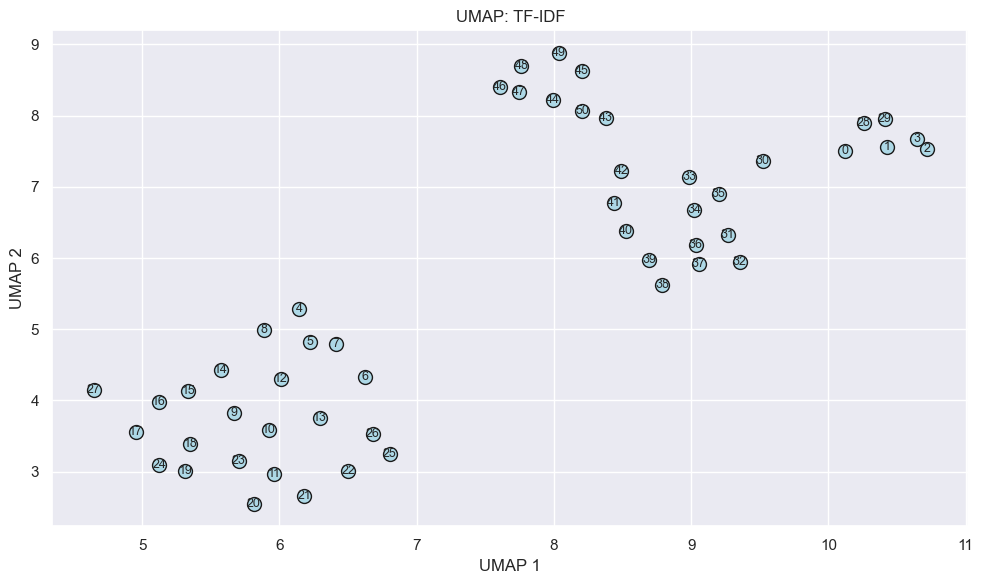

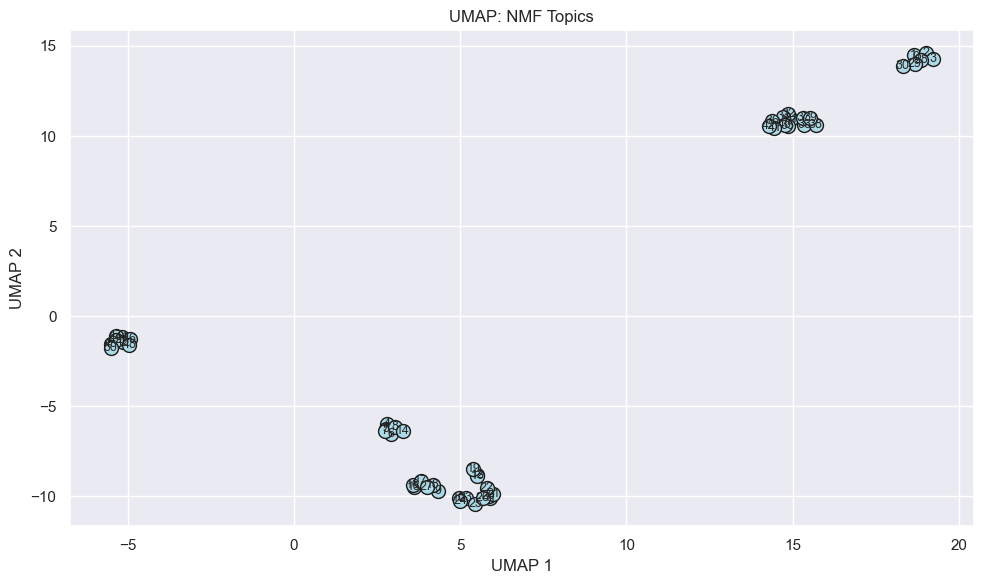

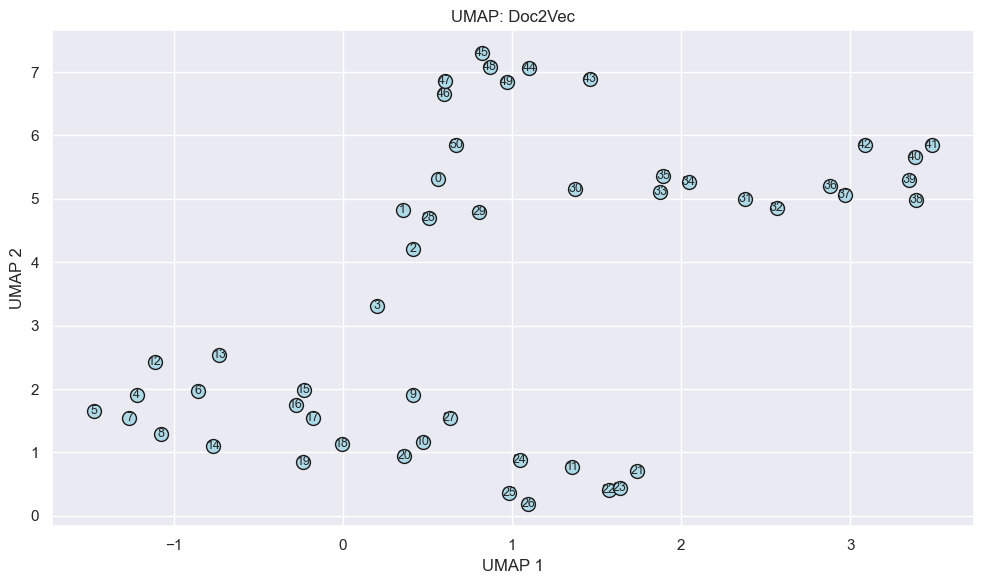

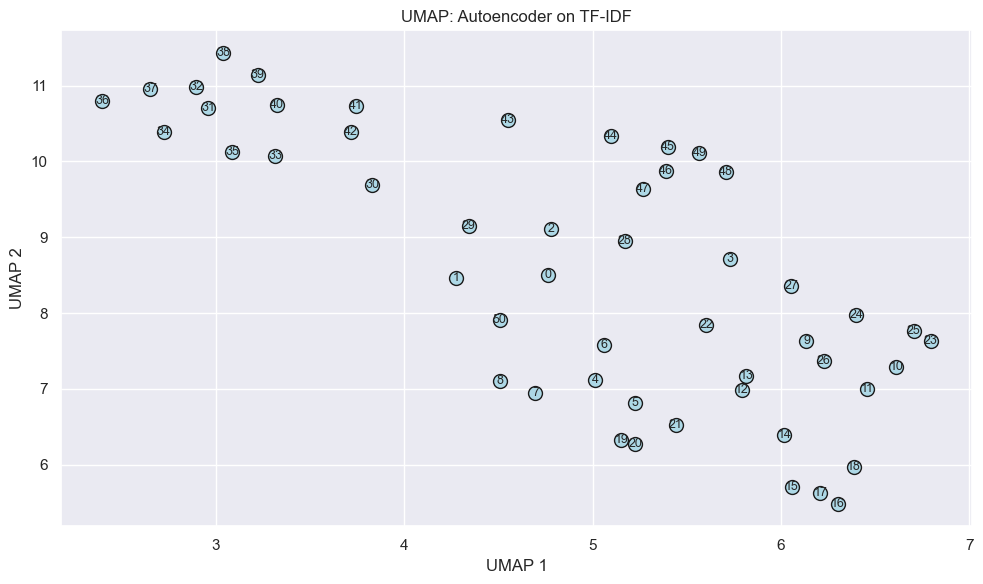

In [142]:
# ==== VISUALIZE UMAPS ====
plot_umap(X_tfidf, "UMAP: TF-IDF", labels=list(range(len(documents))))
plot_umap(X_nmf, "UMAP: NMF Topics", labels=list(range(len(documents))))
plot_umap(X_doc2vec, "UMAP: Doc2Vec", labels=list(range(len(documents))))
plot_umap(X_autoencoded, "UMAP: Autoencoder on TF-IDF", labels=list(range(len(documents))))

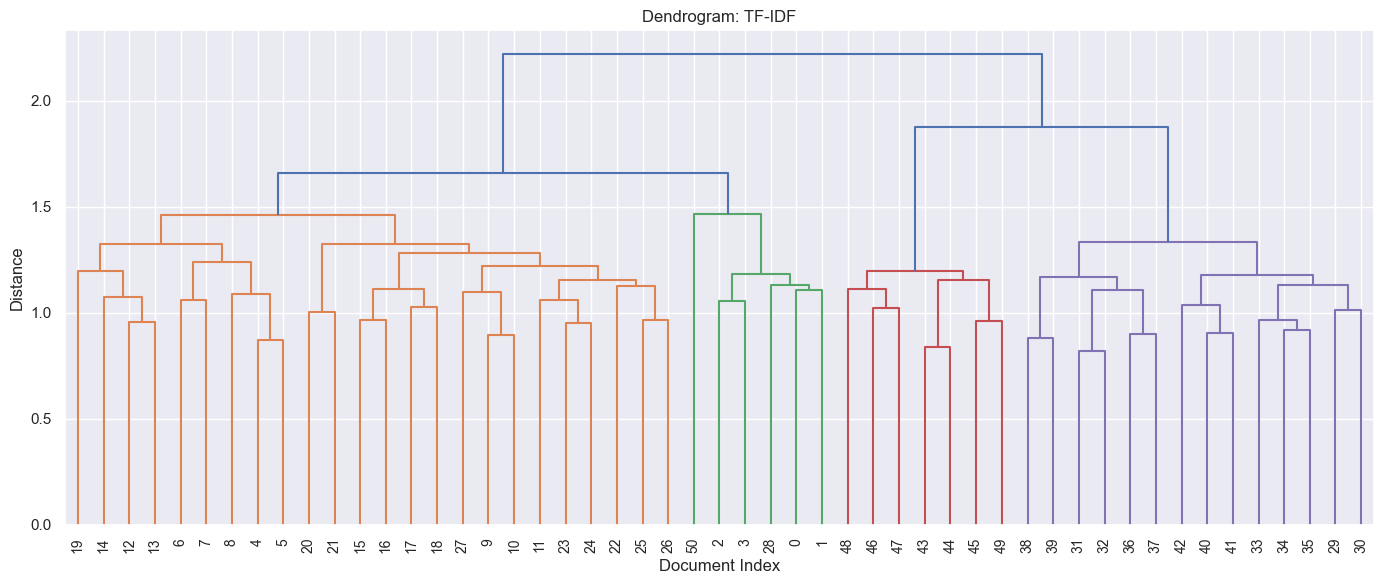

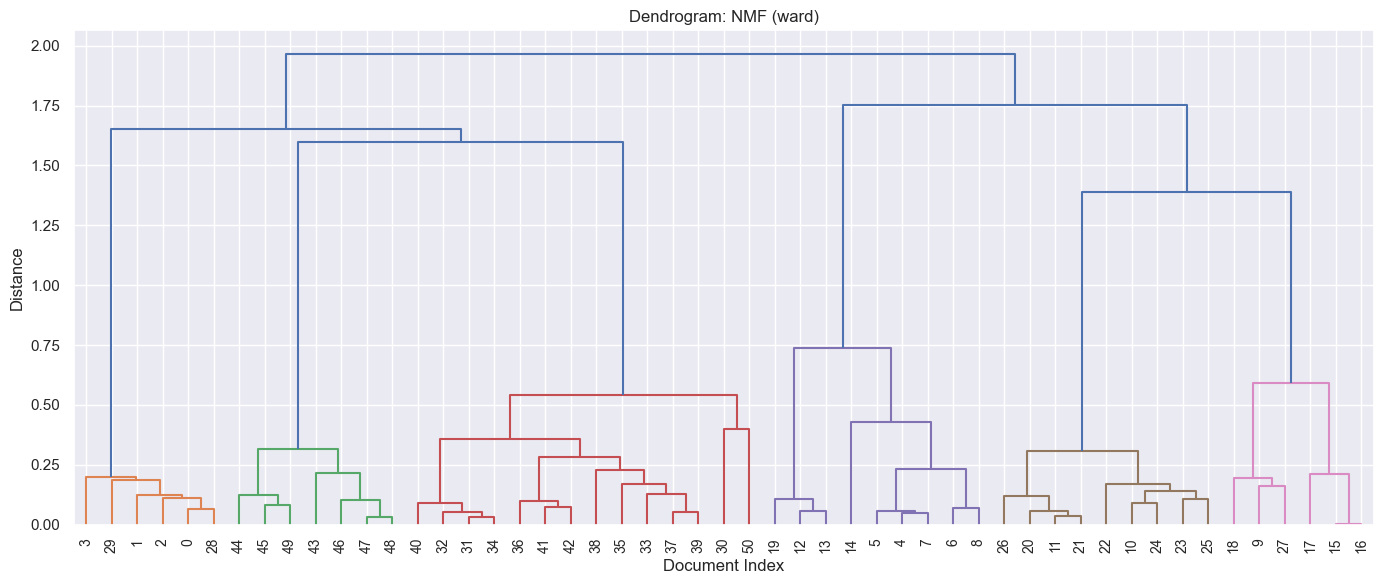

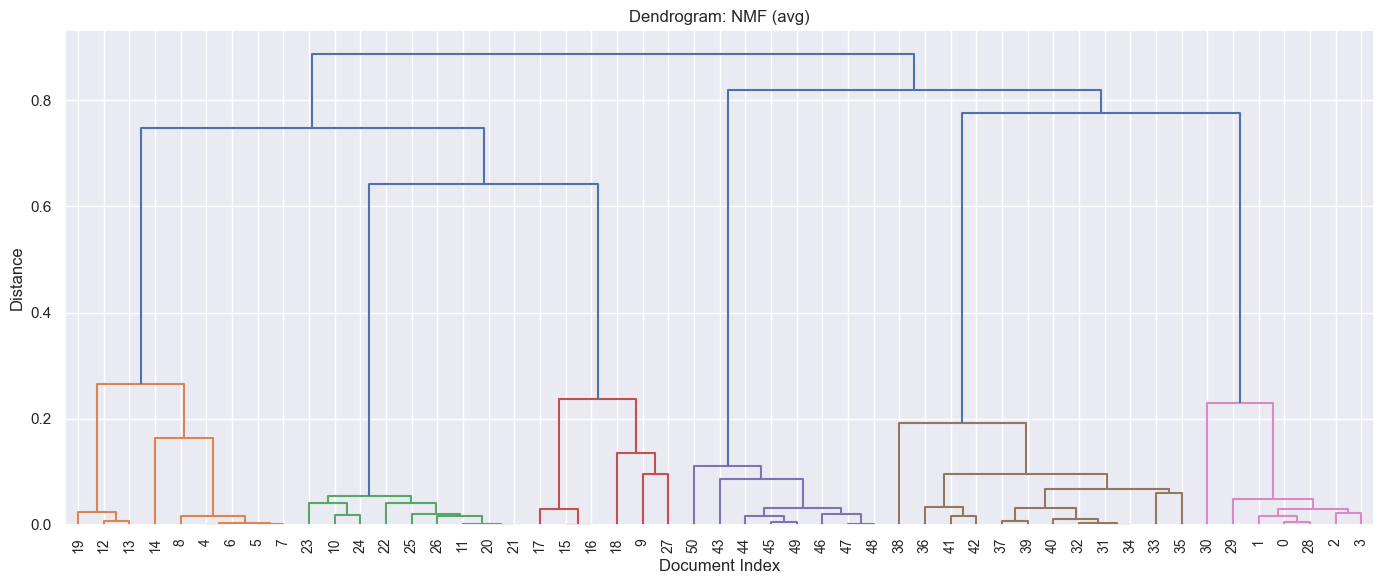

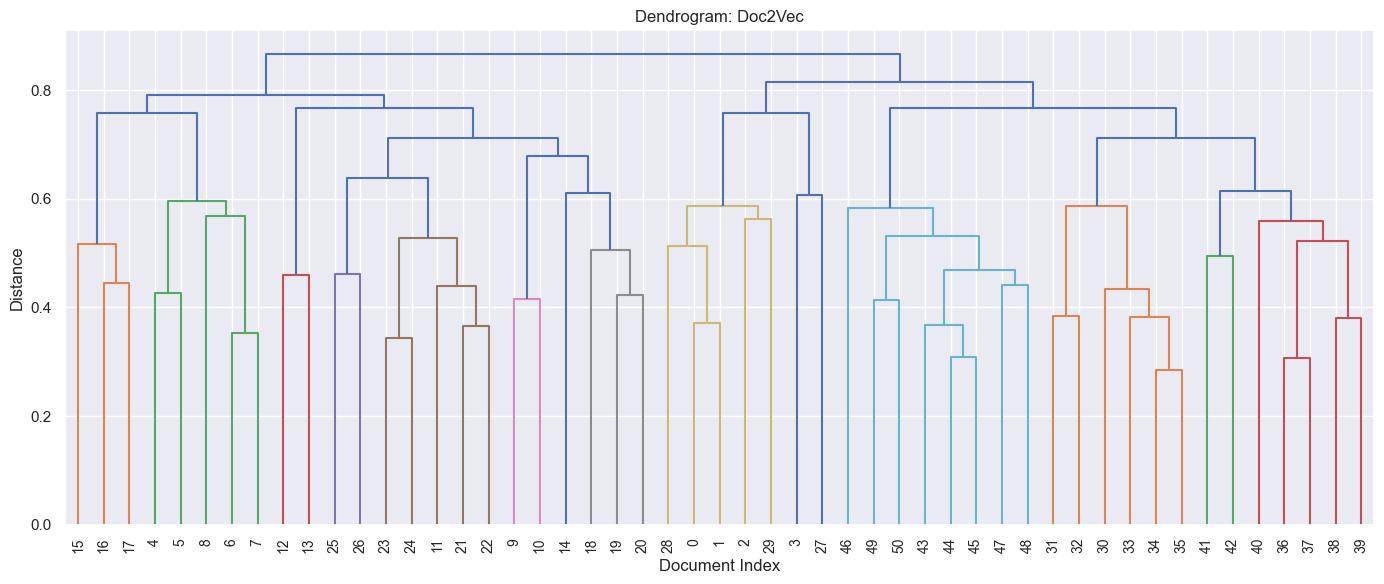

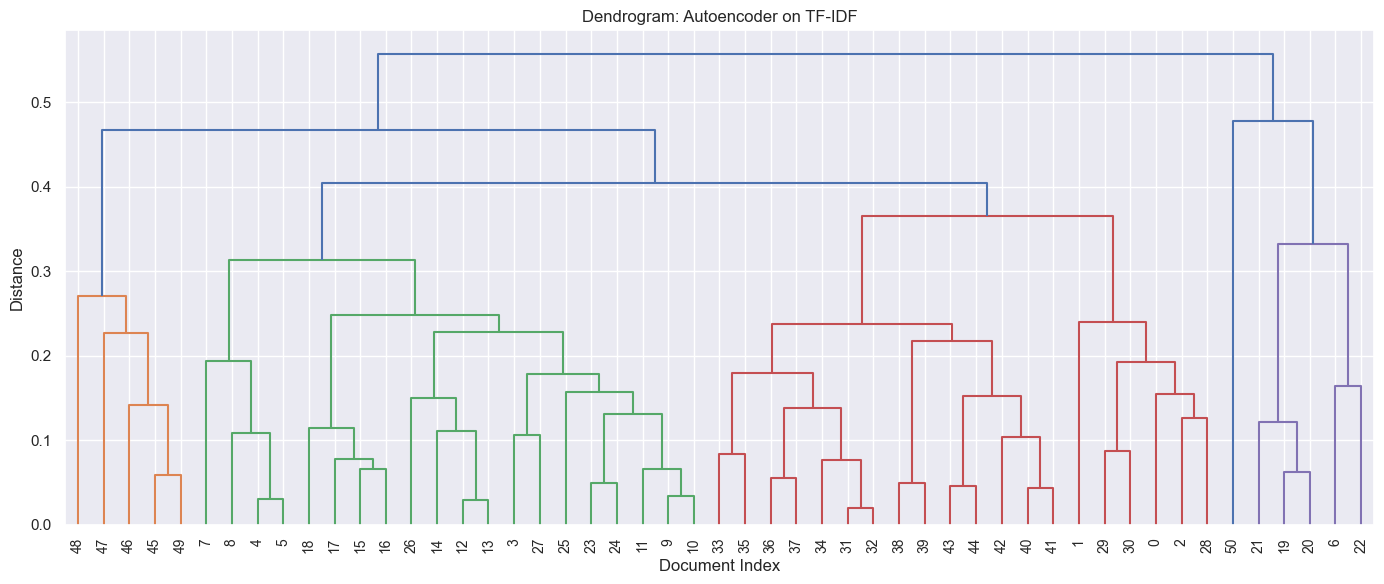

In [143]:
# ==== VISUALIZE DENDROGRAMS ====
plot_dendrogram(X_tfidf, method='ward', metric='euclidean', title='Dendrogram: TF-IDF')
plot_dendrogram(X_nmf, method='ward', metric='euclidean', title='Dendrogram: NMF (ward)')
plot_dendrogram(X_nmf, method='average', metric='cosine', title='Dendrogram: NMF (avg)')
plot_dendrogram(X_doc2vec, method='average', metric='cosine', title='Dendrogram: Doc2Vec')
plot_dendrogram(X_autoencoded, method='average', metric='cosine', title='Dendrogram: Autoencoder on TF-IDF')

In [144]:
import pandas as pd

In [145]:
D2V = pd.DataFrame(X_doc2vec)

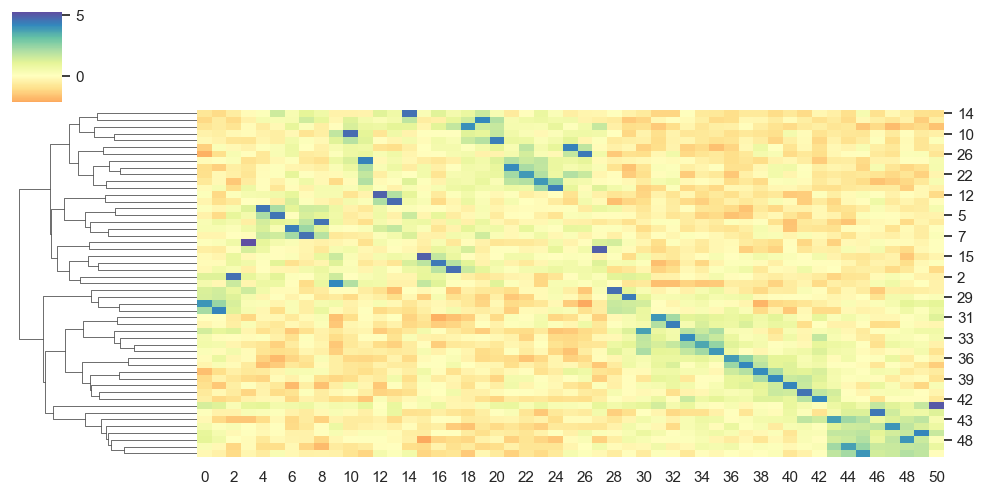

In [146]:
sns.clustermap(D2V.T.corr(), z_score=1, cmap='Spectral', center=0, col_cluster=False, figsize=(10,5))

In [147]:
NMF_ = pd.DataFrame(X_nmf)

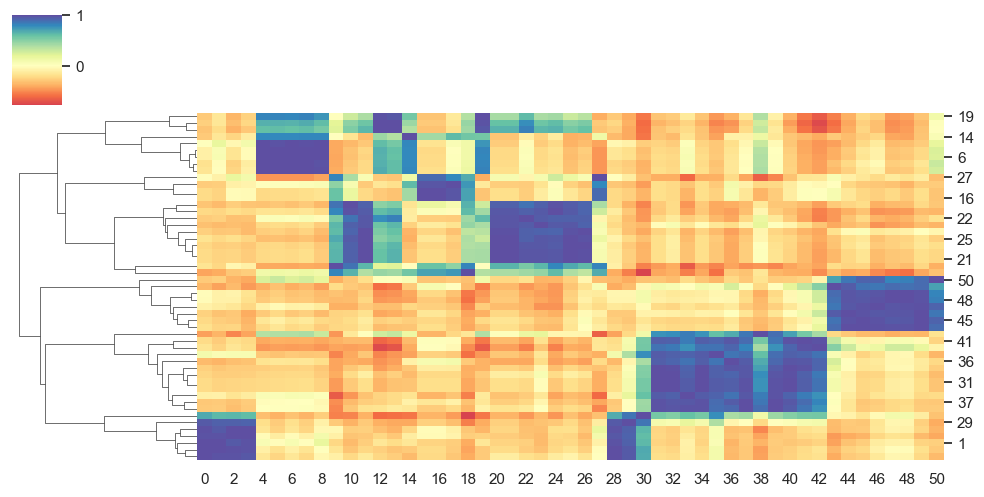

In [148]:
sns.clustermap(NMF_.T.corr(), cmap='Spectral', center=0, col_cluster=False, figsize=(10,5))

In [149]:
TFI = pd.DataFrame(X_tfidf)

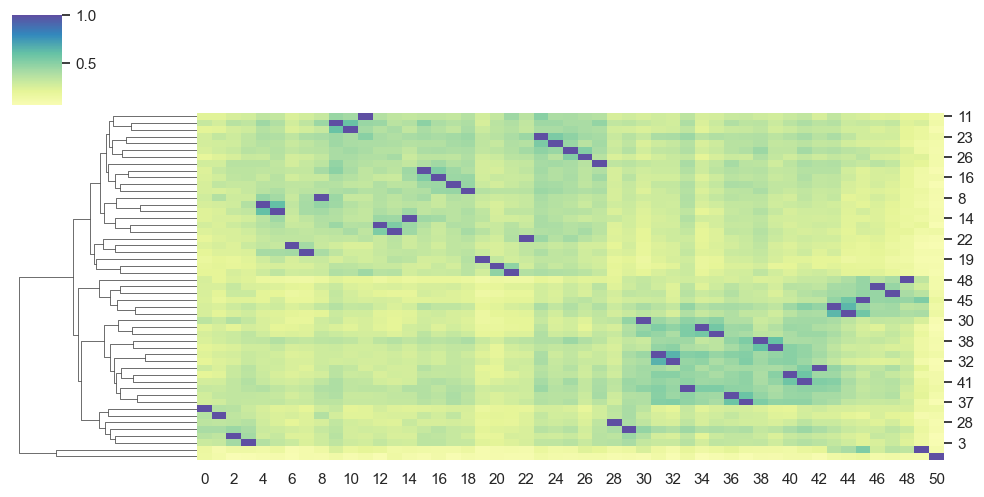

In [165]:
sns.clustermap(TFI.T.corr(), cmap='Spectral', z_score=None, center=0, col_cluster=False, figsize=(10,5))

In [164]:
# sns.clustermap(cosine_distances(TFI), cmap='Spectral', standard_scale=None, center=0, col_cluster=False, figsize=(10,5))

In [204]:
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import squareform

t=6

D = pairwise_distances(X_doc2vec, metric='cosine')
D_condensed = squareform(D, checks=False)
Z = linkage(D_condensed, method='average')
labels = fcluster(Z, t=t, criterion='maxclust')  # t = number of desired clusters

print("LABELS")
for c in set(labels):
    print(f"\nCluster {c}")
    for i in np.where(labels == c)[0]:
        print(f"  Chunk {i}: {documents[i][:60]}...")

LABELS

Cluster 1
  Chunk 4: ta chuxoq rumal chi naj kopon wi nu wach cha ri wuqub kaqix ...
  Chunk 5: e kaxtok xcha ri wuqub kaqix ta xuxekeba u qab ri junajpu ki...
  Chunk 6: wi che raqan ki kabal o much chubinik ta xkiqat kut jun nima...
  Chunk 7: ku ri sipakna xa wi kaslik xuqat uloq rismal u wi xa pu kuku...
  Chunk 8: u tzijoxik ojer u nabe kajol wuqub kaqix chuxe juyub meawan ...
  Chunk 15: kus ku ki waram chiri xeel chi ku chiri xeya chik chuwi kix ...
  Chunk 16: kichelaj kewojon chik kisiloj chik chuqab taq che keje kut k...
  Chunk 17: xkipixab ku katit chire u yaik ki wa chitikoj na qij chibe y...

Cluster 2
  Chunk 12: la wakamik ba la xkis i qij kixkamik xkisachik xkiqaqup puch...
  Chunk 13: chi rochoch ri qapoj xtzaqat kut waqib ik ta xnawachil rumal...

Cluster 3
  Chunk 9: ulew xkul chirij tzikin xutio ma ku ja bi chik naqi la xuban...
  Chunk 10: chuwach ulew ta chikamik are kut kajawarem ajal mes ajal toq...
  Chunk 11: xkukaj xeopon chi a u tukel puj chi a mawi

In [202]:
# Convert correlation to distance
distance_matrix = 1 - TFI.T.corr().values
condensed_dist = squareform(distance_matrix, checks=False)

# Linkage and flat cluster assignment
Z = linkage(condensed_dist, method='average')
cluster_labels = fcluster(Z, t=6, criterion='maxclust')  # Adjust t as needed

In [203]:
for c in sorted(set(cluster_labels)):
    indices = [i for i, label in enumerate(cluster_labels) if label == c]
    print(f"\nCluster {c} ({len(indices)} chunks):")
    for i in indices:
        print(f"  Chunk {i}: {documents[i][:80]}...")


Cluster 1 (7 chunks):
  Chunk 43: ilokab xekuchu kib ronojel amaq xekikotik ta xeulik kokaib ko akutek ko ajaw xaw...
  Chunk 44: are chik tojbal ki mak xuxik rumal ajaw ko tuja ki chi kut xok chi munil xealabi...
  Chunk 45: chuch kam ja are kut ajawab ri chuwach kaweqib belejeb chi ajawab koloje u nim j...
  Chunk 46: chi nay pu rabinaleb ri pa maka u juyub ku kaokeb ri saqkaba ja u tinamit chi ku...
  Chunk 47: pop chire qalej we chok chi ku awe at ajaw qalel qalel ri qalem xchuxik xecha ku...
  Chunk 48: rech qanal raxal at pu yaol mial kajol chatziloj chamaqij uloq a raxal a qanal c...
  Chunk 49: chuwach castillan winaq don juan de rojas don juan cortes kajlaju le ajawab e ka...

Cluster 2 (13 chunks):
  Chunk 30: chila relebal qij balam kitze u mam u qajaw belejeb nim ja chi kawiqib balam aqa...
  Chunk 31: balam kitze balam aqab majukutaj iki balam kekikotik are qa tzukum wa mi xqariqo...
  Chunk 32: jun winaq demonium loquens cis chikiwach ri balam kitze balam aqab majukutaj 